# Patrón 4: Prompt Chaining / Pipeline

### ¿Qué es?

El **Prompt Chaining** descompone una tarea compleja en una secuencia **predeterminada** de pasos LLM. La salida de cada paso es la entrada del siguiente. No hay routing dinámico — el flujo es determinístico.

Caso de uso: Pipeline de análisis de quejas financieras (CFPB Consumer Complaints)

Dataset: Consumer Complaints Dataset for NLP — Kaggle

Fuente original: Consumer Financial Protection Bureau (CFPB) — datos públicos del gobierno de EE.UU. también accesibles directamente en consumerfinance.gov/data-research/consumer-complaints.

¿Qué hace este pipeline?

Recibe el texto libre de una queja financiera y la procesa a través de 5 nodos LLM en secuencia determinística:
* queja_raw → [clean] → [classify] → [sentiment] → [summarize] → [recommend] → reporte final

Dependencias:

```bash
!pip install -q langgraph langchain-anthropic langchain-core pandas kagglehub
```

Diagrama:

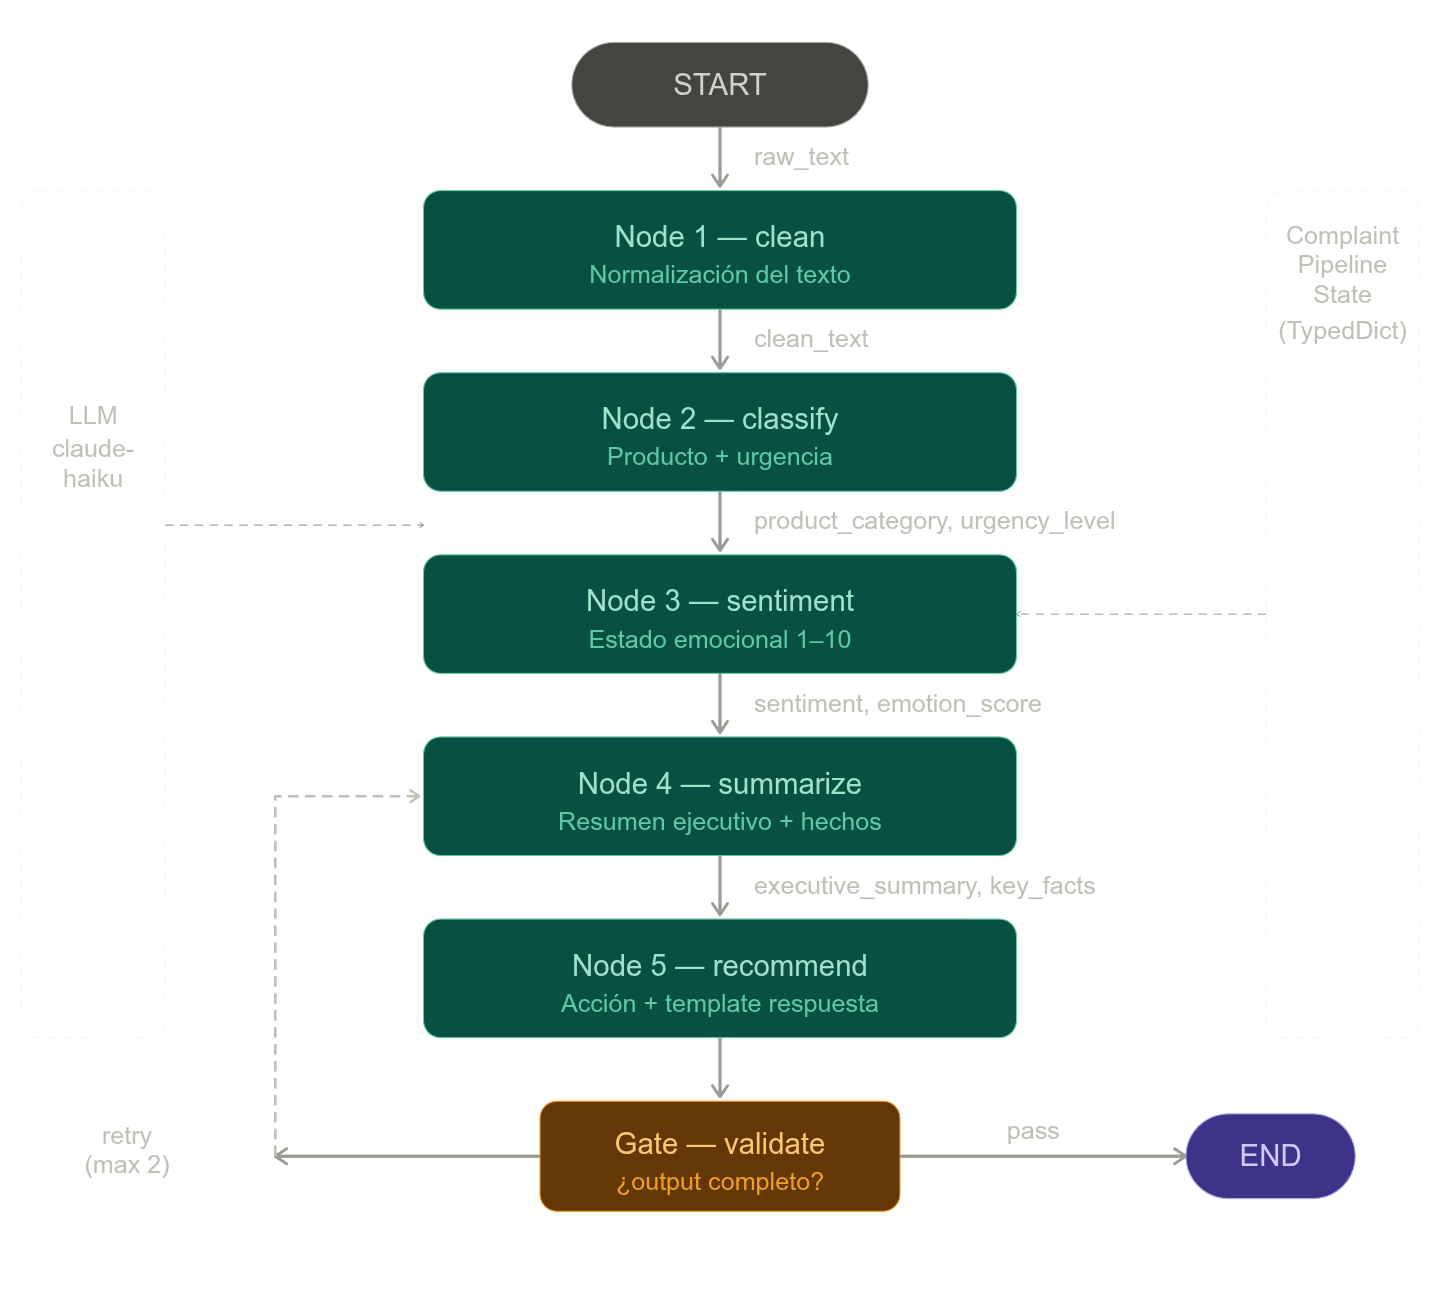

Nodos:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|Entrada|Punto de entrada del grafo|Recibe el estado inicial con complaint_id y raw_text. Conectado via add_edge(START, "clean")|
|ComplaintPipelineState|Estado|Estado compartido entre nodos|TypedDict con 14 campos tipados. Fluye entre todos los nodos; cada nodo lee campos previos y escribe sus propios outputs. Actúa como contrato de interfaz del pipeline.|
|node_clean|Nodo LLM|Limpieza y normalización del texto|Llama al LLM para reemplazar redacciones CFPB (XXXX), corregir errores tipográficos y normalizar el texto. Escribe clean_text al estado. Primer paso del pipeline lineal.|
|node_classify|Nodo LLM|Clasificación de producto financiero y urgencia|Toma clean_text y genera un JSON con product_category (Mortgage, Credit card, etc.), sub_issue y urgency_level (high / medium / low). Usa structured output via parsing de JSON.|
|node_sentiment|Nodo LLM|Análisis del estado emocional del cliente|Consume clean_text, product_category y urgency_level. Devuelve sentiment (frustrated / angry / confused…) y emotion_score (1–10). Enriquece el contexto para los nodos siguientes.|
|node_summarize|Nodo LLM|Generación del resumen ejecutivo|Sintetiza todos los campos acumulados en el estado para producir executive_summary (2–3 oraciones) y key_facts (lista). Es el nodo de mayor carga contextual; también el objetivo del retry en el gate.|
|node_recommend|Nodo LLM|Generación de acción y template de respuesta|Combina resumen y hechos clave para producir recommended_action, evalúa si escalation_required es True (urgencia high o emotion_score ≥ 8), y genera response_template para el agente de atención.|
|gate_validate|Gate condicional|Validación de completitud del output|Verifica 6 checks sobre el estado final (campos no vacíos, urgencia válida, resumen mínimo). Retorna "end" si todos pasan, o "retry" si alguno falla (máximo 2 reintentos). Implementado con add_conditional_edges.|
|node_increment_attempts|Nodo auxiliar|Contador de reintentos|Incrementa validation_attempts en el estado antes de reenviar al nodo summarize. Evita loops infinitos en el retry del gate; el límite es 2 intentos máximo.|
|END|Salida|Punto de terminación del grafo|Alcanzado cuando gate_validate retorna "end". El estado final contiene todos los campos poblados: clasificación, sentimiento, resumen, acción y template.|
|ChatAnthropic (LLM)|Infraestructura|Modelo de lenguaje base|Instancia compartida de claude-haiku-4-5 con temperature=0. Invocada por los 5 nodos LLM. Haiku se elige por velocidad y costo en un pipeline de múltiples llamadas por queja.|
|StateGraph|Infraestructura|Orquestador del grafo|Objeto LangGraph que conecta nodos con add_node, add_edge y add_conditional_edges. Compila el grafo con .compile() y expone .invoke() y .stream() para ejecución.|

### Cuándo usarlo
- ✅ Procesamiento de documentos (extracción → clasificación → transformación)
- ✅ Pipelines de generación de contenido estructurado
- ✅ Cuando el orden de pasos es siempre el mismo
- ✅ Debugging sencillo — cada nodo es una unidad aislada
- ❌ No adecuado si se necesita routing dinámico o paralelismo


In [1]:
!pip install -q langgraph langchain-anthropic langchain-core pandas kagglehub python-dotenv

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
import pandas as pd
from IPython.display import display, Markdown,Image
from typing import TypedDict, Literal, Optional, Annotated
import operator
import json
import urllib.request
import os
import re


In [5]:
from typing import TypedDict, Optional
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from pprint import pprint
import time


### Descarga del dataset desde Kaggle

In [6]:
import kagglehub

path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")
print(f"Dataset descargado en: {path}")

100%|██████████| 19.8M/19.8M [00:06<00:00, 3.00MB/s]

Extracting files...


Dataset descargado en: /home/ernesto/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1


### Exploración del dataset

In [7]:
# Si descargaste con kagglehub
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("Archivos CSV encontrados:", csv_files)
df = pd.read_csv(csv_files[0])

print(f"\nShape: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head(3)

Archivos CSV encontrados: ['/home/ernesto/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1/complaints_processed.csv']

Shape: (162421, 3)

Columnas:
['Unnamed: 0', 'product', 'narrative']

Primeras filas:


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...


In [8]:
sample_complaints = [
    {
        "id": "C001",
        "texto": "I applied for a mortgage refinance with my bank and they kept losing my documents. "
                 "I submitted everything three times and each time they said they never received it. "
                 "After 6 months they denied my application without explanation and now my credit score "
                 "has been affected by multiple hard inquiries they ran without my consent.",
        "producto_real": "Mortgage",
    },
    {
        "id": "C002",
        "texto": "My credit card company charged me a late fee even though I paid on time. "
                 "I have bank statements proving the payment cleared before the due date. "
                 "They refused to reverse the fee and reported me as delinquent to all three credit bureaus. "
                 "This has destroyed my credit and I have been trying to resolve this for 4 months.",
        "producto_real": "Credit card",
    },
    {
        "id": "C003",
        "texto": "A debt collector keeps calling my family members and my employer about a debt that "
                 "was already settled and paid in full two years ago. I have the settlement agreement "
                 "and the paid in full letter but they ignore it. They are threatening to sue me.",
        "producto_real": "Debt collection",
    },
]

print("Quejas de ejemplo cargadas:")
for c in sample_complaints:
    print(f"  [{c['id']}] Producto real: {c['producto_real']} | Chars: {len(c['texto'])}")

Quejas de ejemplo cargadas:
  [C001] Producto real: Mortgage | Chars: 325
  [C002] Producto real: Credit card | Chars: 317
  [C003] Producto real: Debt collection | Chars: 246


### Configuración del LLM y estado del pipeline


In [9]:
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0)  # Haiku: rápido y barato para pipeline
# Alternativa: model="claude-sonnet-4-6" para mayor calidad

print(f"LLM configurado: {llm.model}")

LLM configurado: claude-haiku-4-5-20251001


In [10]:
# ─── Estado del Pipeline ────────────────────────────────────────────────────
class ComplaintPipelineState(TypedDict):
    # Input
    complaint_id: str
    raw_text: str

    # Paso 1: Texto limpio
    clean_text: str

    # Paso 2: Clasificación
    product_category: str
    sub_issue: str
    urgency_level: str   # high / medium / low

    # Paso 3: Análisis de sentimiento
    sentiment: str       # frustrated / angry / confused / neutral
    emotion_score: int   # 1-10 (1=tranquilo, 10=furioso)

    # Paso 4: Resumen ejecutivo
    executive_summary: str
    key_facts: list

    # Paso 5: Recomendación
    recommended_action: str
    escalation_required: bool
    response_template: str

    # Gate de validación
    validation_passed: bool
    validation_attempts: int


print("Estado del pipeline definido con", len(ComplaintPipelineState.__annotations__), "campos")

Estado del pipeline definido con 15 campos


### Definición de los 5 nodos del pipeline

In [11]:
# ─── Nodo 1: Limpieza y normalización ─────────────────────────────────────
def node_clean(state: ComplaintPipelineState) -> dict:
    """Limpia el texto: quita XXX/XXXX (datos redactados por CFPB), normaliza."""
    prompt = f"""Eres un preprocesador de texto para quejas financieras.

TAREA: Limpia y normaliza el siguiente texto de queja:
1. Reemplaza cualquier "XXXX" o "XX/XX/XXXX" por "[REDACTED]"
2. Corrige errores tipográficos obvios
3. Mantén el significado completo y todos los hechos importantes
4. No agregues información que no esté en el original
5. Devuelve SOLO el texto limpio, sin explicaciones

TEXTO ORIGINAL:
{state['raw_text']}

TEXTO LIMPIO:"""

    response = llm.invoke(prompt)
    clean = response.content.strip()
    print(f"  ✅ [clean] {len(state['raw_text'])} → {len(clean)} chars")
    return {"clean_text": clean}


In [12]:
# ─── Nodo 2: Clasificación ─────────────────────────────────────────────────
def node_classify(state: ComplaintPipelineState) -> dict:
    """Clasifica el producto financiero, sub-issue y nivel de urgencia."""
    prompt = f"""Eres un clasificador de quejas financieras del CFPB (Consumer Financial Protection Bureau).

TAREA: Analiza esta queja y devuelve un JSON con la clasificación.

CATEGORÍAS DE PRODUCTO válidas:
- Mortgage | Credit card | Debt collection | Student loan
- Checking or savings account | Credit reporting | Personal loans
- Money transfer | Payday loan | Vehicle loan | Other

NIVELES DE URGENCIA:
- high: menciona acciones legales, pérdida de hogar, fraude confirmado, o daño crediticio severo
- medium: disputa activa, múltiples intentos fallidos de resolución
- low: consulta o queja menor

TEXTO DE LA QUEJA:
{state['clean_text']}

Responde ÚNICAMENTE con este JSON (sin markdown, sin texto adicional):
{{
  "product_category": "...",
  "sub_issue": "descripción breve del problema específico",
  "urgency_level": "high|medium|low"
}}"""

    response = llm.invoke(prompt)
    content = response.content.strip()
    # Limpiar posibles bloques markdown
    content = re.sub(r"```json|```", "", content).strip()
    parsed = json.loads(content)
    print(f"  ✅ [classify] Producto: {parsed['product_category']} | Urgencia: {parsed['urgency_level']}")
    return {
        "product_category": parsed["product_category"],
        "sub_issue": parsed["sub_issue"],
        "urgency_level": parsed["urgency_level"],
    }

In [13]:
# ─── Nodo 3: Análisis de sentimiento ──────────────────────────────────────
def node_sentiment(state: ComplaintPipelineState) -> dict:
    """Analiza el estado emocional del consumidor."""
    prompt = f"""Eres un analista de experiencia del cliente especializado en servicios financieros.

TAREA: Analiza el estado emocional del consumidor en esta queja.

TEXTO:
{state['clean_text']}

CONTEXTO: Esta queja fue clasificada como [{state['product_category']}] con urgencia [{state['urgency_level']}].

Responde ÚNICAMENTE con este JSON (sin markdown):
{{
  "sentiment": "frustrated|angry|confused|anxious|neutral|disappointed",
  "emotion_score": <número del 1 al 10, donde 1=muy calmado y 10=extremadamente furioso>,
  "emotional_triggers": ["lista", "de", "factores", "que", "generaron", "el", "estado", "emocional"]
}}"""

    response = llm.invoke(prompt)
    content = re.sub(r"```json|```", "", response.content.strip()).strip()
    parsed = json.loads(content)
    print(f"  ✅ [sentiment] Estado: {parsed['sentiment']} | Score emocional: {parsed['emotion_score']}/10")
    return {
        "sentiment": parsed["sentiment"],
        "emotion_score": parsed["emotion_score"],
    }


In [14]:
# ─── Nodo 4: Resumen ejecutivo ─────────────────────────────────────────────
def node_summarize(state: ComplaintPipelineState) -> dict:
    """Genera un resumen ejecutivo estructurado para el equipo de atención."""
    prompt = f"""Eres un analista senior de quejas del CFPB. Genera un resumen ejecutivo conciso.

DATOS DE LA QUEJA:
- Producto: {state['product_category']}
- Problema específico: {state['sub_issue']}
- Urgencia: {state['urgency_level']}
- Estado emocional del cliente: {state['sentiment']} (score: {state['emotion_score']}/10)

TEXTO COMPLETO:
{state['clean_text']}

Responde ÚNICAMENTE con este JSON (sin markdown):
{{
  "executive_summary": "Resumen en 2-3 oraciones claras para un agente de atención",
  "key_facts": [
    "Hecho clave 1 (específico y verificable)",
    "Hecho clave 2",
    "Hecho clave 3"
  ]
}}"""

    response = llm.invoke(prompt)
    content = re.sub(r"```json|```", "", response.content.strip()).strip()
    parsed = json.loads(content)
    print(f"  ✅ [summarize] Resumen: {parsed['executive_summary'][:80]}...")
    return {
        "executive_summary": parsed["executive_summary"],
        "key_facts": parsed["key_facts"],
    }


In [15]:
# ─── Nodo 5: Recomendación de acción ─────────────────────────────────────
def node_recommend(state: ComplaintPipelineState) -> dict:
    """Genera la acción recomendada y un template de respuesta al cliente."""
    escalation = state["urgency_level"] == "high" or state["emotion_score"] >= 8

    prompt = f"""Eres un supervisor de resolución de quejas financieras con 10 años de experiencia.

RESUMEN EJECUTIVO:
{state['executive_summary']}

HECHOS CLAVE:
{chr(10).join(f"- {f}" for f in state['key_facts'])}

DATOS ADICIONALES:
- Urgencia: {state['urgency_level']} | Sentimiento: {state['sentiment']} | Score emocional: {state['emotion_score']}/10
- Escalamiento requerido: {"SÍ" if escalation else "NO"}

TAREA: Genera la acción recomendada Y un borrador de respuesta al cliente.

Responde ÚNICAMENTE con este JSON (sin markdown):
{{
  "recommended_action": "Acción específica y concreta que debe tomar el agente (máximo 2 oraciones)",
  "response_template": "Estimado cliente, [template de respuesta empático y profesional de 3-4 oraciones]"
}}"""

    response = llm.invoke(prompt)
    content = re.sub(r"```json|```", "", response.content.strip()).strip()
    parsed = json.loads(content)
    print(f"  ✅ [recommend] Escalamiento: {'🔴 SÍ' if escalation else '🟢 NO'} | Acción: {parsed['recommended_action'][:60]}...")
    return {
        "recommended_action": parsed["recommended_action"],
        "escalation_required": escalation,
        "response_template": parsed["response_template"],
    }


In [16]:
# ─── Gate de validación ────────────────────────────────────────────────────
def gate_validate(state: ComplaintPipelineState) -> str:
    """Valida que el pipeline produjo outputs completos y coherentes. Retorna siguiente nodo."""
    attempts = state.get("validation_attempts", 0)

    checks = [
        len(state.get("clean_text", "")) > 20,
        state.get("product_category", "") != "",
        state.get("urgency_level", "") in ("high", "medium", "low"),
        state.get("sentiment", "") != "",
        len(state.get("executive_summary", "")) > 30,
        len(state.get("recommended_action", "")) > 10,
    ]

    passed = all(checks)
    failed_checks = [i for i, ok in enumerate(checks) if not ok]

    if passed:
        print(f"  ✅ [validate] Todos los checks pasaron → END")
        return "end"
    elif attempts >= 2:
        print(f"  ⚠️  [validate] Máximo de reintentos alcanzado → END forzado")
        return "end"
    else:
        print(f"  🔄 [validate] Checks fallidos: {failed_checks} → reintentando desde node_summarize")
        return "retry"


print("✅ Los 5 nodos del pipeline + gate de validación definidos")


✅ Los 5 nodos del pipeline + gate de validación definidos


### Construcción del grafo LangGraph

In [17]:
def node_increment_attempts(state: ComplaintPipelineState) -> dict:
    """Incrementa el contador de reintentos antes de volver a summarize."""
    return {"validation_attempts": state.get("validation_attempts", 0) + 1}



In [18]:
# ─── Builder ───────────────────────────────────────────────────────────────
builder = StateGraph(ComplaintPipelineState)

# Agregar nodos
builder.add_node("clean",      node_clean)
builder.add_node("classify",   node_classify)
builder.add_node("sentiment",  node_sentiment)
builder.add_node("summarize",  node_summarize)
builder.add_node("recommend",  node_recommend)
builder.add_node("inc_retry",  node_increment_attempts)

In [19]:
# ─── Edges: Flujo lineal fijo (Patrón Pipeline) ───────────────────────────
builder.add_edge(START,        "clean")
builder.add_edge("clean",      "classify")
builder.add_edge("classify",   "sentiment")
builder.add_edge("sentiment",  "summarize")
builder.add_edge("summarize",  "recommend")

In [20]:
# Edge condicional: gate de validación tras recommend
builder.add_conditional_edges(
    "recommend",
    gate_validate,
    {
        "end":   END,          # Todo OK → termina
        "retry": "inc_retry",  # Falla → reintenta
    }
)
builder.add_edge("inc_retry", "summarize")  # Retry va a summarize (último paso de LLM)


In [21]:
# ─── Compilar ──────────────────────────────────────────────────────────────
graph = builder.compile()

print("✅ Grafo compilado exitosamente")
print(f"   Nodos: {list(graph.nodes)}")

✅ Grafo compilado exitosamente
   Nodos: ['__start__', 'clean', 'classify', 'sentiment', 'summarize', 'recommend', 'inc_retry']


### Visualización del grafo


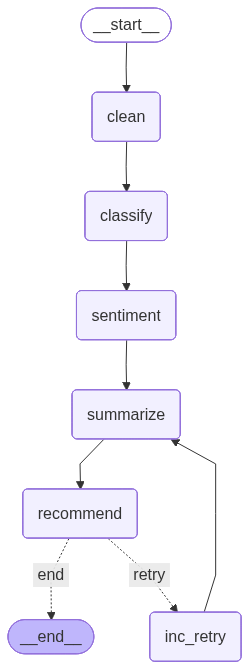

Grafo renderizado ↑


In [23]:
try:
    from IPython.display import Image, display
    img_data = graph.get_graph().draw_mermaid_png()
    display(Image(img_data))
    print("Grafo renderizado ↑")
except Exception as e:
    # Alternativa: imprimir el Mermaid diagram como texto
    print("Diagrama del grafo (Mermaid):")
    print(graph.get_graph().draw_mermaid())

### Ejecución del pipeline con una queja

In [24]:
complaint = sample_complaints[0]  # Queja de hipoteca

print("=" * 70)
print(f"🚀 Ejecutando pipeline para queja: {complaint['id']}")
print(f"   Producto esperado: {complaint['producto_real']}")
print(f"   Texto ({len(complaint['texto'])} chars): {complaint['texto'][:100]}...")
print("=" * 70)

initial_state: ComplaintPipelineState = {
    "complaint_id":        complaint["id"],
    "raw_text":            complaint["texto"],
    "clean_text":          "",
    "product_category":    "",
    "sub_issue":           "",
    "urgency_level":       "",
    "sentiment":           "",
    "emotion_score":       0,
    "executive_summary":   "",
    "key_facts":           [],
    "recommended_action":  "",
    "escalation_required": False,
    "response_template":   "",
    "validation_passed":   False,
    "validation_attempts": 0,
}

result = graph.invoke(initial_state)

print("\n" + "=" * 70)
print("📊 RESULTADO FINAL DEL PIPELINE")
print("=" * 70)

🚀 Ejecutando pipeline para queja: C001
   Producto esperado: Mortgage
   Texto (325 chars): I applied for a mortgage refinance with my bank and they kept losing my documents. I submitted every...
  ✅ [clean] 325 → 325 chars
  ✅ [classify] Producto: Mortgage | Urgencia: high
  ✅ [sentiment] Estado: angry | Score emocional: 9/10
  ✅ [summarize] Resumen: Cliente reporta pérdida repetida de documentación de refinanciamiento hipotecari...
  ✅ [recommend] Escalamiento: 🔴 SÍ | Acción: Abrir investigación formal inmediata sobre pérdida de docume...
  ✅ [validate] Todos los checks pasaron → END

📊 RESULTADO FINAL DEL PIPELINE


### Mostrar resultados formateados

In [25]:
# Celda 9: Mostrar el reporte final estructurado

URGENCY_EMOJI = {"high": "🔴", "medium": "🟡", "low": "🟢"}
SENTIMENT_EMOJI = {
    "frustrated": "😤", "angry": "😡", "confused": "😕",
    "anxious": "😰", "neutral": "😐", "disappointed": "😞",
}

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║          REPORTE DE ANÁLISIS DE QUEJA — PIPELINE CFPB           ║
╚══════════════════════════════════════════════════════════════════╝

📋 ID: {result['complaint_id']}

🏷️  CLASIFICACIÓN
   Producto:  {result['product_category']}
   Sub-issue: {result['sub_issue']}
   Urgencia:  {URGENCY_EMOJI.get(result['urgency_level'], '⚪')} {result['urgency_level'].upper()}

😊 ESTADO EMOCIONAL
   Sentimiento: {SENTIMENT_EMOJI.get(result['sentiment'], '❓')} {result['sentiment']}
   Score:       {result['emotion_score']}/10

📝 RESUMEN EJECUTIVO
   {result['executive_summary']}

📌 HECHOS CLAVE
{chr(10).join(f"   {i+1}. {f}" for i, f in enumerate(result['key_facts']))}

⚡ ACCIÓN RECOMENDADA
   {result['recommended_action']}
   Escalamiento: {"🔴 REQUERIDO" if result['escalation_required'] else "🟢 NO REQUERIDO"}

✉️  TEMPLATE DE RESPUESTA AL CLIENTE
   {result['response_template']}
""")


╔══════════════════════════════════════════════════════════════════╗
║          REPORTE DE ANÁLISIS DE QUEJA — PIPELINE CFPB           ║
╚══════════════════════════════════════════════════════════════════╝

📋 ID: C001

🏷️  CLASIFICACIÓN
   Producto:  Mortgage
   Sub-issue: Pérdida repetida de documentos, denegación sin explicación, y consultas de crédito no autorizadas que afectaron la puntuación crediticia
   Urgencia:  🔴 HIGH

😊 ESTADO EMOCIONAL
   Sentimiento: 😡 angry
   Score:       9/10

📝 RESUMEN EJECUTIVO
   Cliente reporta pérdida repetida de documentación de refinanciamiento hipotecario (3 envíos), denegación de solicitud sin justificación tras 6 meses, y consultas de crédito no autorizadas que impactaron negativamente su puntuación crediticia. Caso de alta urgencia con cliente muy insatisfecho (9/10) que requiere investigación inmediata sobre prácticas de manejo de documentos y cumplimiento de FCRA.

📌 HECHOS CLAVE
   1. Documentación enviada 3 veces y reportada como no reci

### Procesar múltiples quejas en batch

In [26]:
resultados_batch = []

print("🔄 Procesando batch de quejas...\n")
print("─" * 50)

for complaint in sample_complaints:
    print(f"\n▶️  Procesando {complaint['id']} [{complaint['producto_real']}]")

    initial_state: ComplaintPipelineState = {
        "complaint_id":        complaint["id"],
        "raw_text":            complaint["texto"],
        "clean_text":          "",
        "product_category":    "",
        "sub_issue":           "",
        "urgency_level":       "",
        "sentiment":           "",
        "emotion_score":       0,
        "executive_summary":   "",
        "key_facts":           [],
        "recommended_action":  "",
        "escalation_required": False,
        "response_template":   "",
        "validation_passed":   False,
        "validation_attempts": 0,
    }

    start = time.time()
    result = graph.invoke(initial_state)
    elapsed = time.time() - start

    resultados_batch.append({
        "id":                   result["complaint_id"],
        "producto_esperado":    complaint["producto_real"],
        "producto_detectado":   result["product_category"],
        "urgencia":             result["urgency_level"],
        "sentimiento":          result["sentiment"],
        "emotion_score":        result["emotion_score"],
        "escalamiento":         result["escalation_required"],
        "segundos":             round(elapsed, 1),
        "full_result":          result,
    })

    print(f"   ✅ Completado en {elapsed:.1f}s | "
          f"Urgencia: {result['urgency_level']} | "
          f"Escalamiento: {result['escalation_required']}")

print("\n" + "─" * 50)
print(f"✅ Batch completo: {len(resultados_batch)} quejas procesadas")

🔄 Procesando batch de quejas...

──────────────────────────────────────────────────

▶️  Procesando C001 [Mortgage]
  ✅ [clean] 325 → 325 chars
  ✅ [classify] Producto: Mortgage | Urgencia: high
  ✅ [sentiment] Estado: angry | Score emocional: 9/10
  ✅ [summarize] Resumen: Cliente reporta pérdida repetida de documentación de refinanciamiento hipotecari...
  ✅ [recommend] Escalamiento: 🔴 SÍ | Acción: Escalar inmediatamente a equipo de cumplimiento normativo (F...
  ✅ [validate] Todos los checks pasaron → END
   ✅ Completado en 12.4s | Urgencia: high | Escalamiento: True

▶️  Procesando C002 [Credit card]
  ✅ [clean] 317 → 317 chars
  ✅ [classify] Producto: Credit card | Urgencia: high
  ✅ [sentiment] Estado: angry | Score emocional: 9/10
  ✅ [summarize] Resumen: Cliente reporta que su compañía de tarjeta de crédito le cobró una cuota por pag...
  ✅ [recommend] Escalamiento: 🔴 SÍ | Acción: Escalar inmediatamente a equipo legal y cumplimiento normati...
  ✅ [validate] Todos los checks pas

### Resumen del batch en tabla


In [27]:
df_resultados = pd.DataFrame([{k: v for k, v in r.items() if k != "full_result"}
                               for r in resultados_batch])

# Verificar si la clasificación fue correcta
df_resultados["clasificacion_ok"] = (
    df_resultados.apply(
        lambda row: row["producto_esperado"].lower() in row["producto_detectado"].lower(),
        axis=1
    )
)

print("📊 RESUMEN DEL BATCH\n")
print(df_resultados[[
    "id", "producto_esperado", "producto_detectado",
    "urgencia", "sentimiento", "emotion_score",
    "escalamiento", "clasificacion_ok", "segundos"
]].to_string(index=False))

accuracy = df_resultados["clasificacion_ok"].mean()
print(f"\n✅ Accuracy clasificación: {accuracy:.0%}")
print(f"⏱️  Tiempo promedio por queja: {df_resultados['segundos'].mean():.1f}s")
print(f"🔴 Quejas con escalamiento requerido: {df_resultados['escalamiento'].sum()}")

📊 RESUMEN DEL BATCH

  id producto_esperado producto_detectado urgencia sentimiento  emotion_score  escalamiento  clasificacion_ok  segundos
C001          Mortgage           Mortgage     high       angry              9          True              True      12.4
C002       Credit card        Credit card     high       angry              9          True              True      11.9
C003   Debt collection    Debt collection     high       angry              9          True              True      11.6

✅ Accuracy clasificación: 100%
⏱️  Tiempo promedio por queja: 12.0s
🔴 Quejas con escalamiento requerido: 3


### Streaming de ejecución nodo a nodo


In [28]:
# Celda 12: Streaming — ver la ejecución nodo por nodo en tiempo real

print("🔍 Ejecución con streaming (nodo por nodo):\n")

complaint = sample_complaints[1]  # Queja de credit card

initial_state: ComplaintPipelineState = {
    "complaint_id":        complaint["id"],
    "raw_text":            complaint["texto"],
    "clean_text":          "",
    "product_category":    "",
    "sub_issue":           "",
    "urgency_level":       "",
    "sentiment":           "",
    "emotion_score":       0,
    "executive_summary":   "",
    "key_facts":           [],
    "recommended_action":  "",
    "escalation_required": False,
    "response_template":   "",
    "validation_passed":   False,
    "validation_attempts": 0,
}

for step in graph.stream(initial_state):
    node_name = list(step.keys())[0]
    node_output = step[node_name]

    print(f"📍 Nodo ejecutado: [{node_name}]")
    for k, v in node_output.items():
        if isinstance(v, str) and len(v) > 80:
            print(f"   {k}: {v[:80]}...")
        elif isinstance(v, list):
            print(f"   {k}: {v[:2]}{'...' if len(v) > 2 else ''}")
        else:
            print(f"   {k}: {v}")
    print()

🔍 Ejecución con streaming (nodo por nodo):

  ✅ [clean] 317 → 317 chars
📍 Nodo ejecutado: [clean]
   clean_text: My credit card company charged me a late fee even though I paid on time. I have ...

  ✅ [classify] Producto: Credit card | Urgencia: high
📍 Nodo ejecutado: [classify]
   product_category: Credit card
   sub_issue: Erroneous late fee charged despite timely payment; improper delinquency reportin...
   urgency_level: high

  ✅ [sentiment] Estado: angry | Score emocional: 9/10
📍 Nodo ejecutado: [sentiment]
   sentiment: angry
   emotion_score: 9

  ✅ [summarize] Resumen: Cliente reporta que su compañía de tarjeta de crédito le cobró una cuota por pag...
📍 Nodo ejecutado: [summarize]
   executive_summary: Cliente reporta que su compañía de tarjeta de crédito le cobró una cuota por pag...
   key_facts: ['Pago realizado antes de la fecha de vencimiento con comprobantes bancarios de liquidación', 'Cuota por pago atrasado cobrada erróneamente y no revertida por el emisor']...

  ✅ [

###  Inspección del grafo y del estado en cada paso

In [29]:
# Celda 13: Mostrar el diagrama Mermaid del patrón Pipeline

mermaid_diagram = """
graph LR
    START([__start__]) --> CLEAN

    CLEAN["🧹 Node 1: Clean
    Normaliza texto CFPB"]

    CLASSIFY["🏷️ Node 2: Classify
    Producto + Urgencia"]

    SENTIMENT["😊 Node 3: Sentiment
    Estado emocional 1-10"]

    SUMMARIZE["📝 Node 4: Summarize
    Resumen ejecutivo"]

    RECOMMEND["⚡ Node 5: Recommend
    Acción + Template"]

    VALIDATE{"✅ Gate: Validate
    ¿Output completo?"}

    CLEAN --> CLASSIFY
    CLASSIFY --> SENTIMENT
    SENTIMENT --> SUMMARIZE
    SUMMARIZE --> RECOMMEND
    RECOMMEND --> VALIDATE

    VALIDATE -->|"pass"| END([__end__])
    VALIDATE -->|"fail (max 2 reintentos)"| SUMMARIZE

    style START fill:#238636,color:#fff
    style END fill:#6e40c9,color:#fff
    style CLEAN fill:#1f3a6e,color:#79c0ff
    style CLASSIFY fill:#1f3a6e,color:#79c0ff
    style SENTIMENT fill:#1f3a6e,color:#79c0ff
    style SUMMARIZE fill:#1f3a6e,color:#79c0ff
    style RECOMMEND fill:#1f3a6e,color:#79c0ff
    style VALIDATE fill:#1a3320,color:#3fb950
"""

print("Diagrama Mermaid del pipeline:")
print(mermaid_diagram)

# Resumen final del patrón
print("""
╔══════════════════════════════════════════════════════════════════╗
║                 PATRÓN 4: PIPELINE — RESUMEN                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset:  CFPB Consumer Complaints (Kaggle / API pública)      ║
║  Nodos:    5 LLM calls en secuencia + 1 gate de validación      ║
║  Flujo:    clean→classify→sentiment→summarize→recommend         ║
║  Estado:   PipelineState TypedDict compartido entre nodos       ║
║  Retry:    Gate reintenta desde summarize si falla (max 2)      ║
║                                                                  ║
║  Cuándo usar este patrón:                                        ║
║  ✅ ETL de documentos estructurados                              ║
║  ✅ Flujo siempre igual, debugging sencillo                      ║
║  ✅ Cada nodo es una unidad aislada y testeable                  ║
║  ❌ No usar si necesitas routing dinámico o paralelismo          ║
╚══════════════════════════════════════════════════════════════════╝
""")

Diagrama Mermaid del pipeline:

graph LR
    START([__start__]) --> CLEAN

    CLEAN["🧹 Node 1: Clean
    Normaliza texto CFPB"]

    CLASSIFY["🏷️ Node 2: Classify
    Producto + Urgencia"]

    SENTIMENT["😊 Node 3: Sentiment
    Estado emocional 1-10"]

    SUMMARIZE["📝 Node 4: Summarize
    Resumen ejecutivo"]

    RECOMMEND["⚡ Node 5: Recommend
    Acción + Template"]

    VALIDATE{"✅ Gate: Validate
    ¿Output completo?"}

    CLEAN --> CLASSIFY
    CLASSIFY --> SENTIMENT
    SENTIMENT --> SUMMARIZE
    SUMMARIZE --> RECOMMEND
    RECOMMEND --> VALIDATE

    VALIDATE -->|"pass"| END([__end__])
    VALIDATE -->|"fail (max 2 reintentos)"| SUMMARIZE

    style START fill:#238636,color:#fff
    style END fill:#6e40c9,color:#fff
    style CLEAN fill:#1f3a6e,color:#79c0ff
    style CLASSIFY fill:#1f3a6e,color:#79c0ff
    style SENTIMENT fill:#1f3a6e,color:#79c0ff
    style SUMMARIZE fill:#1f3a6e,color:#79c0ff
    style RECOMMEND fill:#1f3a6e,color:#79c0ff
    style VALIDATE fill:#1a3320,